# TP1 Modèles de langue: exploration de la tokenization et des embeddings

Dans ce TP nous allons explorer un peu la tokenization d'un modèle de langue, en regardant par exemple la correspondance avec les mots d'un dictionnaire classique.

Puis nous allons étudier l'espace de représentation des embeddings associés aux sous-tokens dans un modèle, et tester si les mots proches en sens sont tokenisés avec des sous-tokens proches.

Enfin, nous visualiserons les correspondances entre 2 langues dans l'espace des représentations créé par un modèle multilingue.

In [47]:
%%capture
%pip -q install --upgrade pip
%pip -q install transformers  sentence-transformers
# pour faire de la réduction de dimension de l'espace des embeddings
%pip -q install umap-learn
# dictionnaire multilingue de traductions mot -> mot
%pip -q install word2word
%pip -q install matplotlib torch seaborn sklearn pandas plotly nltk gensim==4.3.1 tqdm
%pip -q install torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu118
%pip -q install -U ipywidgets

In [3]:
# lexique de mots anglais
#%wget https://www.irit.fr/~Philippe.Muller/lexicon.txt.gz
#%gunzip lexicon.txt.gz

In [48]:
import numpy as np
import umap
import matplotlib.pyplot as plt
#from sklearn.manifold import TSNE

In [49]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForMaskedLM
import pandas as pds

In [6]:
import torch

if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
device    

device(type='mps')

In [50]:
import os
import warnings
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModel

warnings.filterwarnings('ignore')

# on peut essayer différents modèles, mais seul le dernier est multilingue
MODELBertBaseUncased = "bert-base-uncased"
MODELRobertaBase = "roberta-base"
MODELBertBaseMultilingualCased = "bert-base-multilingual-cased"

MODEL = MODELBertBaseMultilingualCased
#model = AutoModel.from_pretrained(MODEL)
model = AutoModelForMaskedLM.from_pretrained(MODEL)


save_path = "M2_IAFA/TP_M2IAFA/TP_M2_TALNGG/TP_2025/TP1"

def is_tokenizer_saved(path):
    # Vérifie la présence des fichiers tokenizer_config.json et vocab.json/bpe/merges.txt
    return ("tokenizer.json" in os.listdir(path) or "tokenizer_config.json" in os.listdir(path))

def is_model_saved(path):
    # Vérifie la présence du fichier de poids PyTorch
    return "pytorch_model.bin" in os.listdir(path)

if os.path.exists(save_path) and is_tokenizer_saved(save_path) and is_model_saved(save_path):
    tokenizer = AutoTokenizer.from_pretrained(save_path)
    # AutoModelForMaskedLM ajoute une tête de langage masquée pour la prédiction de tokens masqués
    model = AutoModelForMaskedLM.from_pretrained(save_path)
    # charge uniquement le corps du modèle (transformer) et retourne les états cachés (embeddings contextuels).
    # model = AutoModel.from_pretrained(save_path)
    print("Le modèle ET le tokenizer ont été rechargés depuis", save_path)
else:
    print("Modèle ou tokenizer manquant : création d’un nouveau")
    tokenizer = AutoTokenizer.from_pretrained(MODEL)
    #model = AutoModel.from_pretrained(MODEL)
    model = AutoModelForMaskedLM.from_pretrained(MODEL)
    # Optionnel : sauvegarde s’ils n’existent pas
    tokenizer.save_pretrained(save_path)
    model.save_pretrained(save_path)
model = model.to(device)    


Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Le modèle ET le tokenizer ont été rechargés depuis M2_IAFA/TP_M2IAFA/TP_M2_TALNGG/TP_2025/TP1


In [51]:
print(f'tokenizer.vocab_size : {tokenizer.vocab_size}') 
print(f'tokenizer.model_max_length : {tokenizer.model_max_length}') 
print(f'tokenizer.special_tokens_map : {tokenizer.special_tokens_map}') 
print(f'tokenizer.all_special_tokens : {tokenizer.all_special_tokens}') 
print(f'tokenizer.all_special_ids : {tokenizer.all_special_ids}') 

tokenizer.vocab_size : 119547
tokenizer.model_max_length : 512
tokenizer.special_tokens_map : {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}
tokenizer.all_special_tokens : ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']
tokenizer.all_special_ids : [100, 102, 0, 101, 103]


`Correspond au vocabulaire complet appris par le tokenizer associé au modèle choisi`

In [9]:
print(f'{tokenizer.get_vocab()}')
print(f'\nnombre de mots : {len(tokenizer.get_vocab())}')

{'ἱ': 1705, '##纏': 116066, 'Twitter': 24309, '##洙': 114732, '##sök': 68621, '##аја': 96012, '##ாள்': 56316, '##álních': 48952, '鄒': 7841, '─': 1836, 'Thirty': 79446, '##cines': 92481, '##侯': 112062, '##љно': 97475, 'हुन्छ': 40108, 'vilket': 17755, 'ata': 21695, 'tank': 28671, '##dring': 105585, '##áticas': 47786, 'nenhum': 68703, '伏': 2220, 'Kathy': 67888, '##ణి': 78576, 'Liang': 59141, '##淋': 114804, '##اك': 40446, '##ωσίας': 105279, 'Hispan': 75148, 'Ponta': 68989, 'ruch': 88077, 'nhóm': 24770, 'uso': 13829, '##隔': 118013, 'יעקב': 49310, 'cantora': 43363, '##nchi': 52750, 'гӀалин': 110229, '##げ': 111790, 'wichtig': 103099, 'Population': 11996, '1463': 77217, 'mitologia': 66283, '##вих': 34527, '##tera': 22833, '##쟈': 119203, '##诡': 117107, '##ură': 41299, '420': 24253, '##晖': 114163, '##иан': 101587, 'gathering': 88666, 'الدولية': 45221, 'ge': 46503, '癮': 5708, 'деякі': 52353, 'disabuik': 27269, 'Hicks': 77224, '##icular': 72550, '##륙': 118898, 'Králové': 69136, 'noch': 11230, 'しない':

In [52]:
pathfile = "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TALNGG/TP_2025/TP1/lexicon.txt"
lexicon = set([x.strip() for x in open(pathfile).readlines()])

__`BPE (Byte-Pair Encoding) utilisé en tokenisation pour les modèles de langage`__    
 - BPE est une technique de découpage lexicale qui construit un vocabulaire de sous-mots à partir d’un corpus textuel. 
 - Il a été popularisé dans la traduction automatique, puis dans les architectures de LLM comme GPT, BERT et RoBERTa.

# Tokenization

__- A quoi correspondent les symboles spéciaux ?__

`Créer un dictionnaire qui associe à chaque mot du lexique la liste des sous-tokens qui le composent`
(pour être plus efficace, vous pouvez prendre la liste des sous-mots générés à la 1er question; la 2e question est également importante !)


|Attribut             |  Description                                                                                                                                   
---------------------|------------------------------------------------------------------------------------------------------------------------------------------------
ids                  |  <br> • Liste des identifiants numériques (token IDs) des sous‑mots obtenus. <br> • Chaque ID correspond à une entrée du vocabulaire (tokenizer.get_vocab()).
tokens               |  <br> • Liste des sous‑mots (chaînes de caractères) correspondant aux IDs, <br> • par exemple[Ġrun, ning].                                                   
offsets              |  <br> • Coordonnées (début, fin) du token dans le texte original en indices de caractère, <br> . utiles pour aligner texte et sous‑mots.                     
type_ids             |  <br> • Indique à quel segment appartient chaque token (utile dans les modèles à deux séquences <br> • comme BERT : 0 pour la première, 1 pour la seconde).  
attention_mask       |  <br> • Valeurs 1 / 0 indiquant quels tokens doivent être pris en compte (1) ou ignorés comme padding (0).                                            
special_tokens_mask  |  <br> • Marque quels tokens sont spéciaux <br> • début de séquence (`<s>`), fin (`</s>`), masque[MASK], etc.                                                   
overflowing          |  <br> . Contient les encodages supplémentaires si le texte dépassait la longueur maximale permise ; <br> • liste d’Encodingsupplémentaires.                  

:::

`Récupérer tous les sous-mots utilisés faites donner la fréquence d'apparition des mots`.

 - Appliquer le tokenizer associé aux modèles listés plus haut, pour tous les mots du lexique anglais faire comptage à l'aide du module `collections.Counter`, le faire en un seul appel au tokenizer, pas mot à mot.

_Que peut-on dire des plus fréquents ?_

 - Les sous‑tokens les plus fréquents que l'on observe reflètent surtout la morphologie de l’anglais et la manière dont WordPiece segmente les mots, pas une « sémantique » propre à ces fragments.

 - Ces sous‑tokens jouent un rôle de « briques » productives : ils permettent de construire efficacement une grande variété de formes dérivées et fléchies à partir d’un vocabulaire de taille limitée, ce qui est exactement l’objectif de WordPiece/BPE.

:::


In [189]:
# En résumé : 
#  tokenize() donne des tokens textuels intermédiaires, 
subtokens = tokenizer.tokenize(
                    " ".join(lexicon),
                    add_special_tokens=False, padding=False,
                    truncation=False, return_tensors=None
                    )

print("Nombre de sub-token : ",len(subtokens))

from collections import Counter
freqs = Counter(subtokens)
print("Sous-tokens les plus fréquents : ", freqs.most_common(5))

for word, enc in zip(lexicon, subtokens[:4]):
    print(f'{word} "→"{enc}')

Nombre de sub-token :  314484
Sous-tokens les plus fréquents :  [('-', 3445), ('##d', 2873), ('##y', 2564), ('##e', 2445), ('##ly', 2014)]
warmly "→"warm
despisal "→"##ly
meride "→"des
uneasy "→"##pis


`tokenizer()`.  
 - list(lexicon) transforme le set en liste de mots.  
 - lorsque l'on passe une liste au tokenizer, il la traite comme un batch de séquences : encodage par mot.
 - add_special_tokens=False évite l`ajout de [CLS], [SEP], etc.    
 - l’objet retourné, pour un tokenizer fast, contient un attribut .encodings
 - l'attribut .encodings est une liste d’objets Encoding, un par mot. 
 - chaque Encoding stocke notamment les ids et les tokens résultants

In [159]:
# tokenizer() donne les IDs numériques finaux prêts pour le modèle
encoded = tokenizer(list(lexicon), add_special_tokens=False).encodings  # liste d'Encoding
subtokenList = []

for enc in encoded:
    for tok in enc.tokens:
        subtokenList.append(tok)
   
print("Nombre de sub-token : ",len(subtokenList))
freqs = Counter(subtokenList)
print("Sous-tokens les plus fréquents : ", freqs.most_common(5),"\n")

sub_tokenList = []
for word, enc in zip(lexicon, encoded[:4]):
    sub_tokenList.append((word, enc))
    print(f' - {word} "→"{enc.tokens} "→" {enc.ids}')

Nombre de sub-token :  314484
Sous-tokens les plus fréquents :  [('-', 3445), ('##d', 2873), ('##y', 2564), ('##e', 2445), ('##ly', 2014)] 

 - warmly "→"['warm', '##ly'] "→" [50089, 10454]
 - despisal "→"['des', '##pis', '##al'] "→" [10139, 16825, 10415]
 - meride "→"['meri', '##de'] "→" [94992, 10253]
 - uneasy "→"['une', '##asy'] "→" [10231, 93789]


# `Analyse des embeddings de base préentrainés`

__Charger un des modèles avec la library transformers avec AutoModelForMaskedLM__.  
 - Affichez la structure du modèle 
 - Trouver la matrice d'embeddings des sous tokens du vocabulaire du modèle.
 - Quelle est sa taille ? Quelle est la dimension des embeddings ?

In [147]:
if MODEL.startswith("bert"):
        base = model.bert
elif MODEL.startswith("roberta"):
        base = model.roberta
else:
    print("unknown model",MODEL)

emb_matrix = base.embeddings.word_embeddings
print(f'emb_matrix : {emb_matrix._parameters["weight"].shape}\n')
print(base.embeddings)

emb_matrix : torch.Size([119547, 768])

BertEmbeddings(
  (word_embeddings): Embedding(119547, 768, padding_idx=0)
  (position_embeddings): Embedding(512, 768)
  (token_type_embeddings): Embedding(2, 768)
  (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


In [148]:
base

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(119547, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=Fals

## `Similarité de mots`

- Testez la similarité de deux sous-tokens qui sont aussi des mots (pour faire plus simple), en utilisant la similarité cosinus (dans torch.nn) entre leur vecteur d'embedding de base.

- Testez aussi quelques mots de langues différentes avec le modèle multilingue
(par exemple chien/dog)

In [152]:
token_ids1 = tokenizer.encode("university", add_special_tokens=False)
token_ids2 = tokenizer.encode("school", add_special_tokens=False)

embeddings = base.embeddings.word_embeddings
# Place les index sur le même device que le modèle
token_tensor1 = torch.tensor(token_ids1, device=device)
token_tensor2 = torch.tensor(token_ids2, device=device)

emb_vec1 = embeddings(token_tensor1).mean(dim=0)
emb_vec2 = embeddings(token_tensor2).mean(dim=0)

cos = torch.nn.CosineSimilarity(dim=0)
output = cos(emb_vec1, emb_vec2)
print(output.item())

0.4916093349456787


`Un score de similarité cosinus de 0.4916 entre les embeddings de "school" et "university" indique que ces deux mots sont modérément similaires dans l’espace sémantique du modèle RoBERTa`.    
 - 1 : vecteurs identiques (alignés parfaitement)
 - 0 : vecteurs orthogonaux (aucune similarité)
 - -1 : opposés (réciproques parfaits)

::: 

__`Pourquoi effectuer une moyenne sur les sous-tokens ?`__  

Lorsqu’on tokenise un mot avec BPE / WordPiece, il a toutes les chances d'être découpé en tokens:

- "university" → ['un', 'iversity']

Chaque sous-mot ayant son propre vecteur d’embedding, donne une matrice [nombre_de_sous_tokens, dimension]

__`Problème :`__

 - Comparer 2 mots avec la similarité cosinus, requiert un vecteur pas une matrice de vecteur de sous-token.

__`Solution classique :`__ 

 - `Pooling des embeddings` : On agrège tous les vecteurs sous-token d’un mot en un seul vecteur.

 - `Moyenne (mean)` : La moyenne (.mean(dim=0)) est la méthode la plus simple et courante, elle combine les informations de tous les sous-tokens, donnant un “embedding mot” unique. Cela fonctionne bien pour la plupart des tâches de comparaison de sens, clustering, retrieval, etc.

__`Exemples alternatifs : `__

 - Moyenne pondérée
 - Somme
 - Pooling max

:::

# `Visualisation`

Nous effectuons une réduction de dimension visualisant les régularités de l'espace des embeddings ("espace latent").     
Pour ce faire utilisons la méthode UMAP qui est adaptée aux grande dimensions, avec les paramètres suivants :

In [114]:
# vous pouvez faire varier les 2 premiers pour voir, mais attention le calcul est assez long
params={"n_neighbors":10,
        "min_dist":0.2,
        "n_components":2,
        "metric":"euclidean",
       }

On peut appeler la méthode comme suit.

In [127]:
reducer = umap.UMAP(random_state=42,**params)
# méthode alternative plus lente
# reducer = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=3)
# extrait la matrice des embeddings du modèle 
initial_embed_matrix = base.embeddings.word_embeddings.weight
print(f'initial_embed_matrix.shape : {initial_embed_matrix.shape}')
# attention meme umap va prendre quelques minutes ! (~5mn dans colab)
redux = reducer.fit_transform(initial_embed_matrix.detach().cpu().numpy())
print(f'redux.shape : {redux.shape}')

initial_embed_matrix.shape : torch.Size([119547, 768])
redux.shape : (119547, 2)


`redux est maintenant une nouvelle représentation des sous-tokens dans un espace en 2 dimensions.`.  
 - sa taille est de [119547, 2] pour UMAP1 et UMAP2  

`On va visualiser seulement les sous-tokens les plus courants pour ne pas trop surcharger.`.   
 - Récupérer les indices des N=1000 (par exemple) sous-tokens les plus courants à partir du comptage fait plus haut.


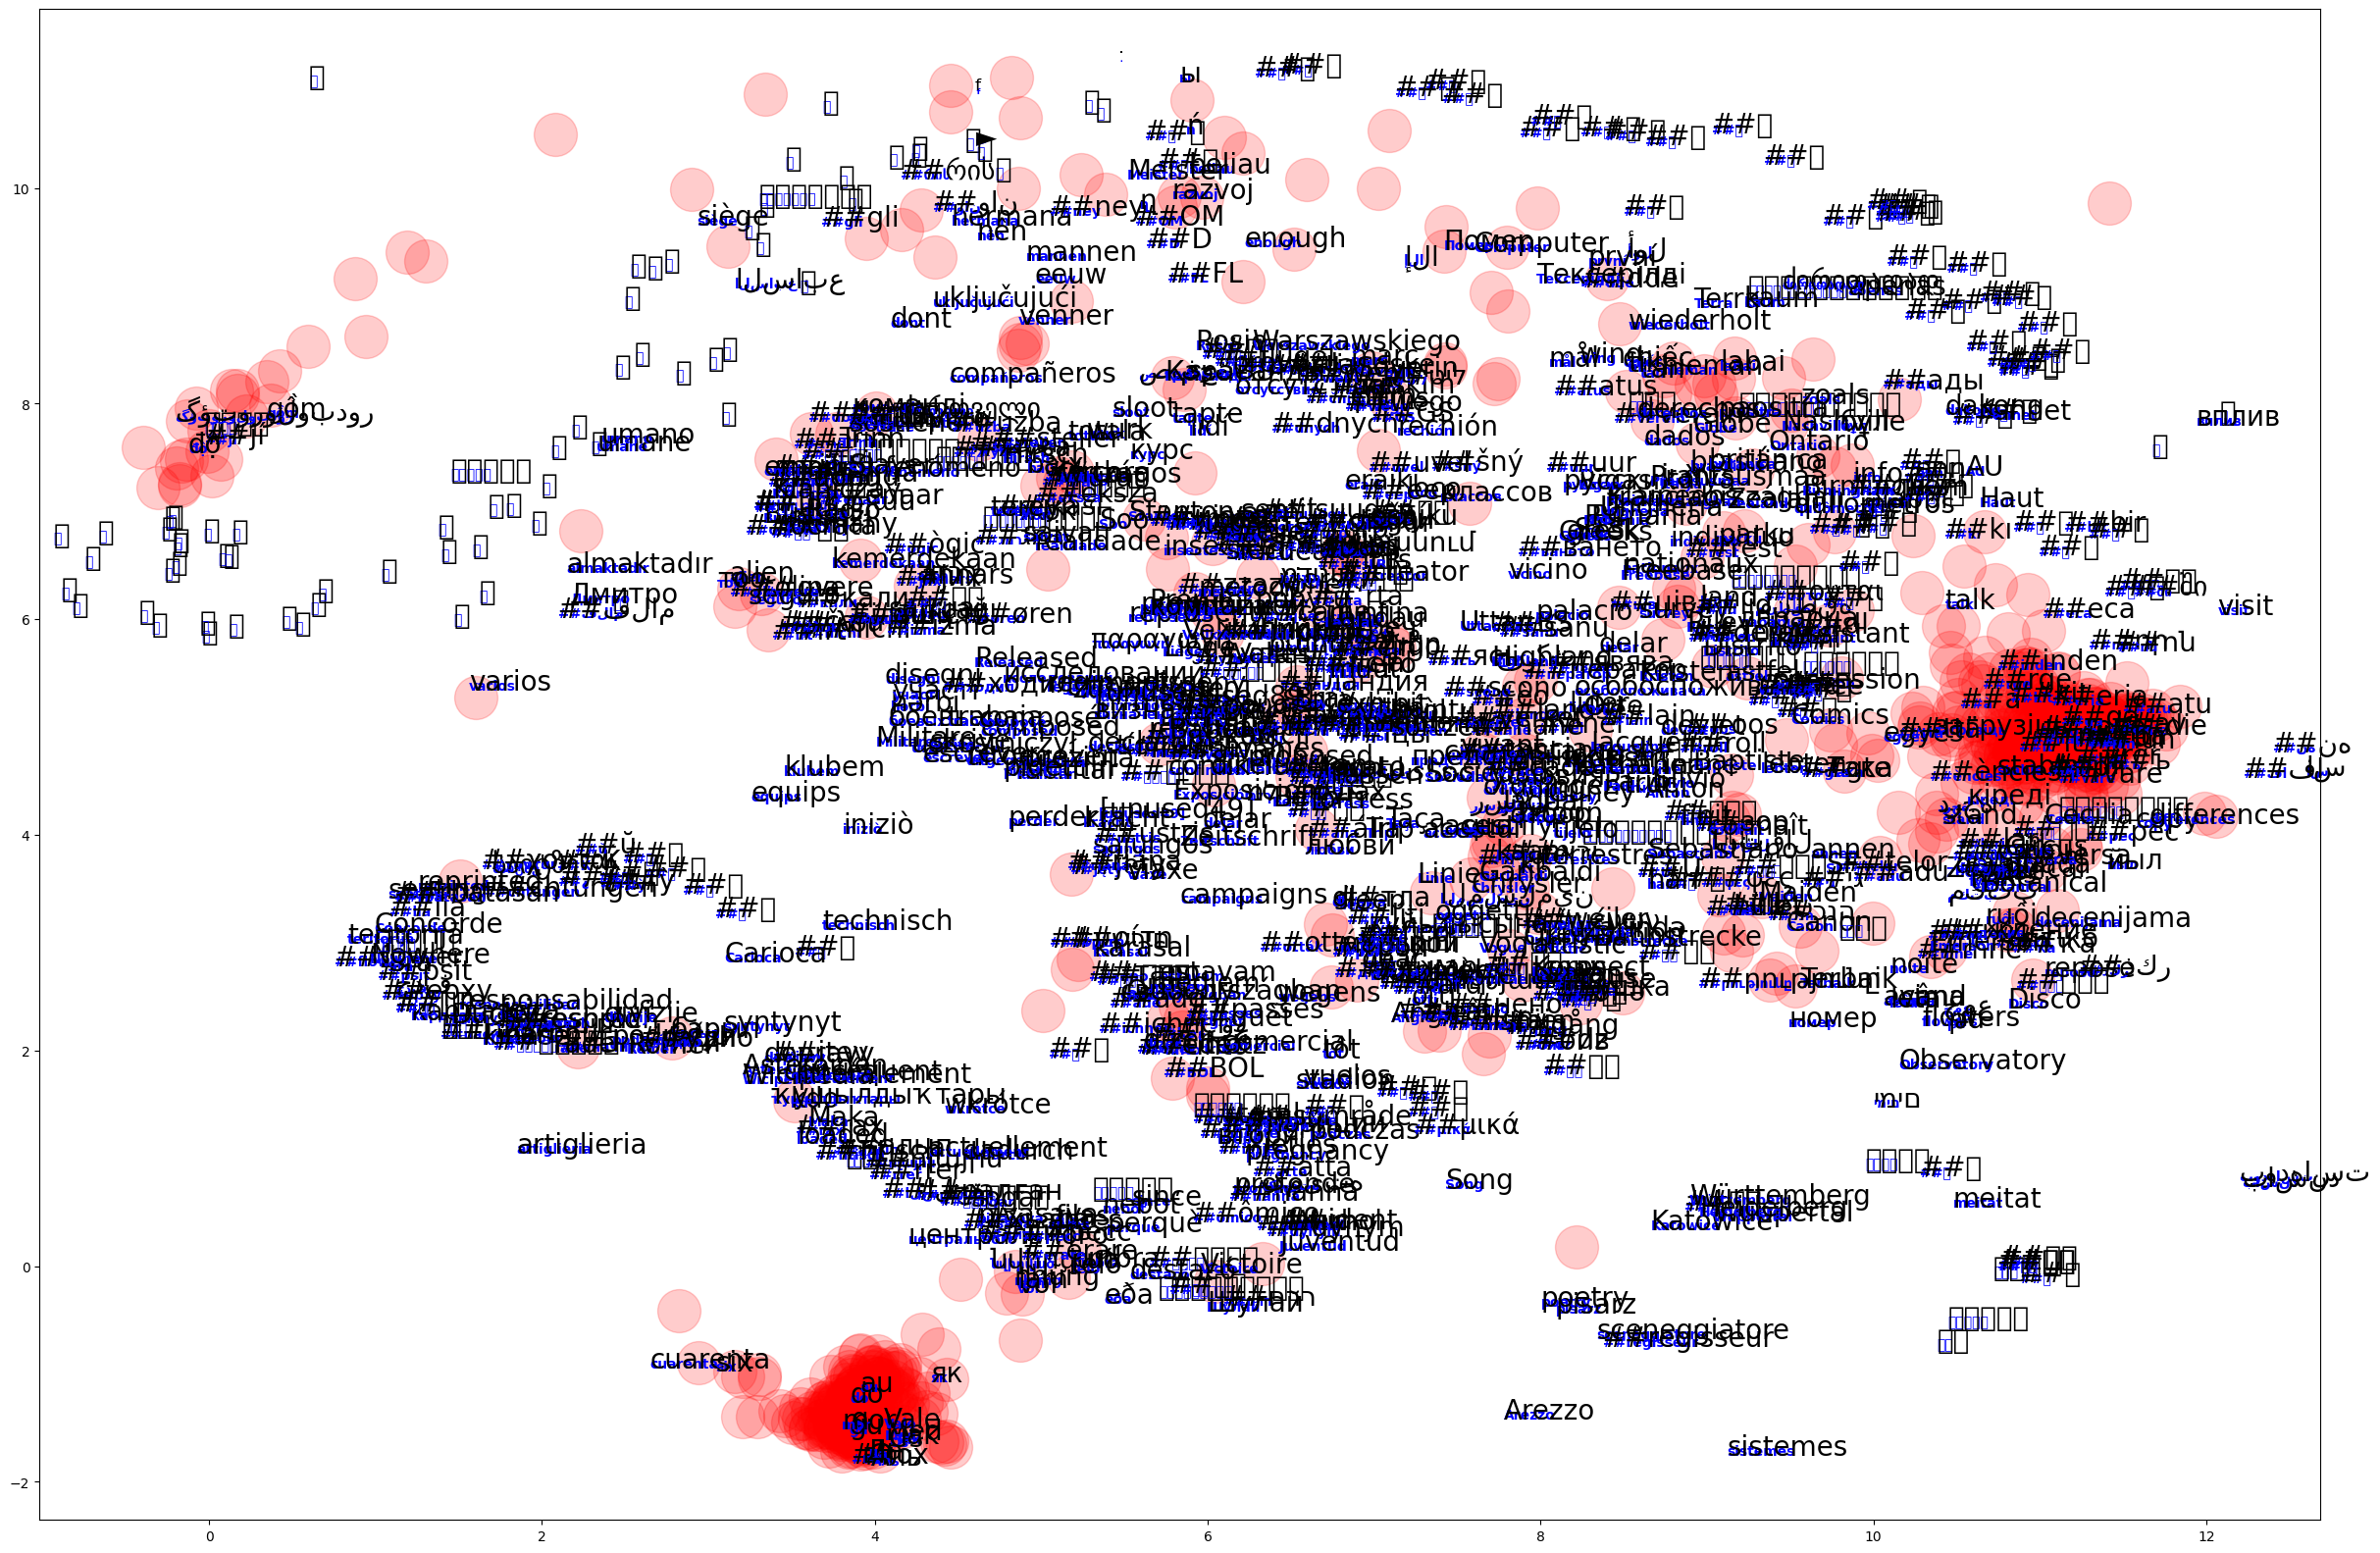

In [161]:
from numpy import random
# ce code affiche la projection en 2D, avec la chaine correspondant à chaque sous-token pour un échantillon au hasard
# remplacez l'échantillon par les N sous-tokens les plus courants et observez la différence

N = 1000
freqs = Counter(subtokenList)
top = freqs.most_common(N)
# Extrais la liste des tokens (textes)
top_tokens = [tok for tok, _ in top]

# Convertis en liste d’IDs (entiers) utilisables comme indices
top_ids = [tokenizer.convert_tokens_to_ids(tok) for tok in top_tokens]
top_ids = np.array(top_ids, dtype=int)

# Maintenant tu peux indexer redux...
top100_pt = redux[top_ids]
fig, ax = plt.subplots(figsize=(30, 20))
plt.scatter(top100_pt[:,0], top100_pt[:,1],s=1000,c="r",alpha=0.2)
#
sample = random.randint(redux.shape[0],size=1000)
for idx in list(sample.data):
    ax.annotate(tokenizer.convert_ids_to_tokens(idx),redux[idx],size=10,c="blue",weight="bold")
    ax.annotate(tokenizer.convert_ids_to_tokens(idx),redux[idx],size=20)

# `Traduction / mapping entre langues`

On va charger un dictionnaire bilingue avec la librairie word2word:

In [76]:
import word2word
en2fr = word2word.Word2word("en", "fr")

`Pour simplifier on va juste regarder la première traduction proposée pour chaque mot anglais qui est un sous-token dans un modèle multilingue comme mBert`.

In [77]:
# contenu du dictionnaire ?
en2fr.__dict__.keys()

dict_keys(['lang1', 'lang2', 'word2x', 'y2word', 'x2ys', 'summary'])

In [78]:
print(f'langue 1 : {en2fr.lang1}, langue 2 : {en2fr.lang2}, type :  {type(en2fr)}') 

langue 1 : en, langue 2 : fr, type :  <class 'word2word.word2word.Word2word'>


`Vérifiez le contenu du mapping en2fr`, 
 - prendre un exemple, et calculez le mapping sous-token anglais -> mot français qui est aussi un sous-token du modèle.

In [235]:
# test
from itertools import islice

print(f"en2fr(basket) : {en2fr('basket')}")
vocab = tokenizer.get_vocab()
print(f'vocab : {dict(islice(vocab.items(),5))}')

en2fr(basket) : ['panier', 'corbeille', 'linge', 'œufs', 'pique-nique']
vocab : {'##dert': 46256, 'presenter': 76527, 'esposo': 98473, '##arni': 73482, '##аза': 34402}


In [ ]:
# %pip -q install nltk

Note: you may need to restart the kernel to use updated packages.


`Vérifiez le contenu du mapping en2fr`, 

 - calculez le mapping sous-token anglais -> mot français qui est aussi un sous-token du modèle.
 - Cela nous donnera un ensemble de mot en/fr qui sont dans le vocabulaire des sous-tokens du modèle.

In [236]:
import string

en_fr_compatible = []

for en_word in vocab.keys():
    try: 
        fr_word = en2fr(en_word)
        if fr_word is not None :
            en_fr_compatible.append((en_word, fr_word))
    except KeyError:
     continue  # Ne fait rien si le mot n'est pas traduisible

en_fr_compatible[2]        

('Orange', ['Orange', 'ô', 'Guillaume', 'Alerte', 'oranges'])

`On va maintenant regarder pour chaque token "anglais" quel est le token "français" le plus proche: calculez cette association avec la similarité cosinus.`


In [237]:
def cosine_similarity(vec1, vec2):
    return (vec1 @ vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

In [238]:
def get_word_embeddings(word):
    token_id = tokenizer.encode(word, add_special_tokens=False)
    embeddings = base.embeddings.word_embeddings
    with torch.no_grad():
        emb_vec = embeddings(torch.tensor(token_id, device=device))
        if emb_vec.shape[0] > 1 :
            emb = emb_vec.mean(axis=0)
        else:
            emb = emb_vec[0]
        return emb

`On va regarder pour chaque token "anglais" quel est le token "français" le plus proche`: 

- calculez cette association avec la similarité cosinus. On peut sauver le tout dans une table pandas.

In [ ]:
from torch.nn import CosineSimilarity

candidates = dict(en_fr_compatible)
cosineSimilarity = CosineSimilarity(dim=0)

results=[]
for eng_word, fr_candidates in candidates.items():
    scores = [cosineSimilarity(get_word_embeddings(eng_word), get_word_embeddings(word)) for word in fr_candidates]
    best_idx = scores.index(max(scores))
    best_fr  = fr_candidates[best_idx]
    results.append((eng_word, best_fr, float(max(scores))))
results_df = pds.DataFrame(results, columns=['English', 'French', 'Similarity'])
results_df   

,English,French,Similarity
0,Philips,Philips,1.000000
1,Passion,Passion,1.000000
2,Mitchell,Mitchell,1.000000
3,adopted,adopté,0.633025
4,Sandy,Sandy,1.000000
...,...,...,...
14432,Visa,Visa,1.000000
14433,sexual,sexuelle,0.628603
14434,Sherman,Sherman,1.000000
14435,Edge,Eagle,0.247735


`Distribution des similarités`. 

- Regardons les valeurs à 1, et les valeurs élevées mais <1 (par exemple 0.5-.99)
- Les embeddings ne sont pas bilingues, il se base sur la sytaxe pas la sémantique.

Si le modèle n’est pas entraîné explicitement pour aligner anglais et français dans le même espace rien ne garantit que emb("castle") soit proche de emb("château").​

Même dans un modèle multilingue , l’alignement inter‑langues est souvent imparfait au niveau token/mot isolé, et se manifeste plutôt à l’échelle de phrases.

## `Analyse`

__Que peut-on dire des mots les plus proches ?__
- Ils ont une syntaxe proches d'une langue à l'autre. 

Si nous souhaitons vérifier que les traductions soient toujours proches nous allons reprendre la projection de l'espace latent en affichant les traductions et la distance mot-traduction dans la figure en utilisant le code suivant (doit générer la figure exemple ou approchant).

In [85]:
%pip -q install plotly

Note: you may need to restart the kernel to use updated packages.


__`UMAP` ("Uniform Manifold Approximation and Projection")__     
__`T-SNE` ("t-distributed Stochastic Neighbor Embedding")__ 

- Sont deux méthodes non-linéaires utilisées pour projeter des données de haute dimension (par exemple les embeddings de mots du modèle) dans un espace de faible dimension (typiquement 2D ou 3D).

- `UMAP` est destiné à la réduction de dimensionnalité pour la visualisation ou l’analyse de grands ensembles  d’embeddings. 

In [182]:
reducer = umap.UMAP(random_state=42,**params)
# méthode alternative plus lente
# reducer = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=3)
# extrait la matrice des embeddings du modèle    
initial_embed_matrix = base.embeddings.word_embeddings.weight
print(f'initial_embed_matrix.shape : {initial_embed_matrix.shape}')
# attention meme umap va prendre quelques minutes ! (~5mn dans colab)
redux = reducer.fit_transform(initial_embed_matrix.detach().cpu().numpy())
print(f'redux.shape : {redux.shape}')
redux_df = pds.DataFrame(redux, columns=['UMAP1', 'UMAP2'])
redux_df.head()

initial_embed_matrix.shape : torch.Size([119547, 768])
redux.shape : (119547, 2)


,UMAP1,UMAP2
0,5.578598,5.514141
1,5.439946,4.886151
2,5.618607,4.750669
3,5.390585,4.967885
4,5.305949,5.513036


In [ ]:
# Remplacez par ce que vous avez trouvé comme ensemble de mots qui sont des mots anglais et des mots français.
# le code suppose que target a
#  - des champs x et y pour les coordonnées de la projection umap
#  - un champ pour dire dans quel langue le token est un mot

#  optionnellement: (la figure peut se faire sans mais c'est moins intéressant)
#  - un champ tok qui donne la chaine du token
#  - un champ french_word pour la traduction du mot en français (si mot pas français)
#  - un champ distance pour la distance cosinus entre le mot et sa traduction

# Récupère le vocabulaire sous forme triée par index
vocab = tokenizer.get_vocab()
id2tok = {v:k for k, v in vocab.items()}
# Associe chaque ligne de la matrice réduite au token correspondant
redux_df['tok'] = [id2tok[i] for i in range(len(redux_df))]
# Merge des données pour obtenir les champs supplémentaires
en_part = results_df.merge(redux_df, left_on='English', right_on='tok')
en_part['lang'] = 'en'

en_part = en_part.rename(columns={
    'English': 'tok',
    'French': 'french_word',
    'Similarity': 'distance',
    'UMAP1': 'x',
    'UMAP2': 'y'})

fr_part = results_df.merge(redux_df, left_on='French', right_on='tok')
fr_part['lang'] = 'fr'
fr_part = fr_part.rename(columns={'French': 'tok', 'English': 'english_word'})

# Garde uniquement la première occurrence de chaque colonne
en_part = en_part.loc[:,~en_part.columns.duplicated()]
fr_part = fr_part.loc[:,~fr_part.columns.duplicated()]

In [89]:
%pip -q install 'nbformat>=4.2.0' 

Note: you may need to restart the kernel to use updated packages.


In [247]:
# visualisation interactive des tokens
import plotly.express as px

target = pds.concat([en_part, fr_part],ignore_index=True)
fig = px.scatter(target, x="x", y="y", color="lang",template="seaborn",
                 color_discrete_sequence=['green','black'],
                 hover_name='tok',width=1200, height=800,
                 hover_data=["french_word","distance"])

fig.update_traces(opacity=.1)
fig.show()

# Question Bonus:

refaire la visualisation de l'espace latent avec la projection finale des mots anglais passés dans le modèle *encodeur*

vous pouvez utiliser les fonctions suivantes qui appelent un modèle encodeur sur une liste de mot et récupérent les activations de chaque couche moyennées sur les sous-tokens d'un mot

vous pouvez le faire avec un échantillon de mots au hasard

In [248]:
# appel du modèle + recup toutes les couches visées en les sommant
def get_hidden_states(encoded, token_ids_word, model, layers):
    # inference
    with torch.no_grad():
        output = model(**encoded,output_hidden_states=True)
    # get all hidden states
    states = output.hidden_states
    # stack and sum layers
    output = torch.stack([states[i] for i in layers]).sum(0).squeeze()
    # subset for tokens that make up the word, averaged on subtokens
    word_tokens_output = output[token_ids_word]
    return word_tokens_output.mean(dim=0)

# encode the sentence, get vector representing the word at index idx for given layers
def get_word_vector(sent, idx, tokenizer, model, layers, device):
    # tokenize the input sentence and sending to device
    encoded = tokenizer.encode_plus(sent, add_special_tokens=True, return_tensors="pt").to(device)
    # get all token idxs that make up the target word
    token_ids_word = np.where(np.array(encoded.word_ids()) == idx)
    # get all hidden states
    return get_hidden_states(encoded, token_ids_word, model, layers)

# main function to get encoding vector of given word occuring in a given sentence
# layers = set of layers to average for the representation
# if want only the last one call with layers = [-1]
def get_embedding(model, tokenizer, sent, word, device, layers=None):
    # using last four layers by default
    layers = [-4, -3, -2, -1] if layers is None else layers
    # get idx for the word
    idx = sent.split(" ").index(word)
    # get word embedding
    word_embedding = get_word_vector(sent, idx, tokenizer, model, layers, device)
    return word_embedding

Si tu disposes d’un corpus annoté (ex: Wikipedia dump, Wikipedia sentences, Common Crawl, OpenSubtitles…), tu peux récupérer pour chaque mot une phrase contenant ce mot :

In [249]:
import nltk
nltk.download('gutenberg')
from nltk.corpus import gutenberg

corpus = gutenberg.sents()
# Pour tout rassembler en phrases
corpus_sentences = [" ".join(sent) for sent in corpus]

[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/asriel/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [250]:
sample_words = []
contexts = []
already_taken = set()

for sent in corpus_sentences:
    words = [w.lower() for w in sent.split() if w.isalpha() and len(w) > 3]
    # Exclure les mots déjà sélectionnés
    uniques = [w for w in words if w not in already_taken]
    if not uniques:
        continue
    word = random.choice(uniques)
    sample_words.append(word)
    contexts.append(sent)
    already_taken.add(word)
    # Option : arrêter à un certain N
    if len(sample_words) >= N:
        break

In [251]:
# 3. Obtenir les embeddings contextuels pour chaque mot
contextual_embeddings = []
valid_words = []

for word, context in zip(sample_words, contexts):
    try:
        # Utilise les 4 dernières couches par défaut
        embedding = get_embedding(model, tokenizer, context, word, device)
        contextual_embeddings.append(embedding.cpu().numpy())
        valid_words.append(word)
    except:
        # Ignore les mots qui causent des erreurs (pas dans la phrase, etc.)
        continue

# 4. Créer la matrice des embeddings contextuels
contextual_matrix = np.array(contextual_embeddings)
print(f"Matrice contextuelle: {contextual_matrix.shape}")

# 5. Appliquer UMAP sur les représentations contextuelles
reducer = umap.UMAP(random_state=42, n_components=2, n_neighbors=15, min_dist=0.1)
contextual_redux = reducer.fit_transform(contextual_matrix)

# 6. Créer le DataFrame pour la visualisation
contextual_df = pds.DataFrame(contextual_redux, columns=['UMAP1', 'UMAP2'])
contextual_df['word'] = valid_words
contextual_df['type'] = 'contextual'

# 7. Ajouter les traductions si disponibles
contextual_df = contextual_df.merge(
    results_df[['English', 'French', 'Similarity']], 
    left_on='word', 
    right_on='English', 
    how='left'
)
contextual_df = contextual_df.dropna(subset=['French', 'Similarity'])

Matrice contextuelle: (944, 768)


In [252]:
# 8. Visualisation interactive
fig = px.scatter(
    contextual_df, 
    x='UMAP1', 
    y='UMAP2',
    hover_name='word',
    hover_data=['French', 'Similarity'],
    title="Représentations contextuelles des mots anglais (couches encodeur)",
    width=1200, 
    height=800
)

fig.update_traces(opacity=0.7, marker=dict(size=8))
fig.show()